# Libs

In [1]:
import matplotlib.pyplot as plt 
import numpy as np 

# %pip install emi-receiver
from emi_receiver import receiver

# UTILS

In [2]:
def raw_to_volte(raw, dic):
    y_increment =  float(dic["y_increment"])
    y_origin =  float(dic["y_origin"])
    y_offset =  float(dic["y_offset"])
    voltage = (raw - y_offset) * y_increment + y_origin
    return voltage 



# CM DIFF V1

50.0 Mhz


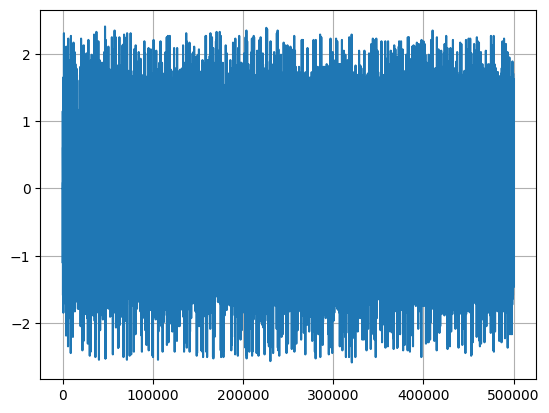

In [3]:
path = "EMI_2026-02-09_15-36-08-718/CH2_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
ycm=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")
plt.plot(ycm)
plt.grid()

50.0 Mhz


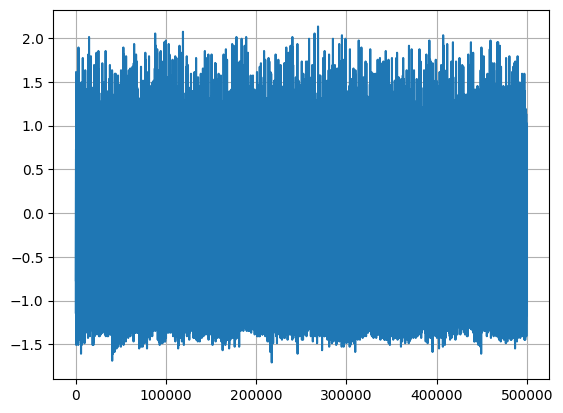

In [4]:
path = "EMI_2026-02-09_15-39-21-346/CH2_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
ydm=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")
plt.plot(ydm)
plt.grid()

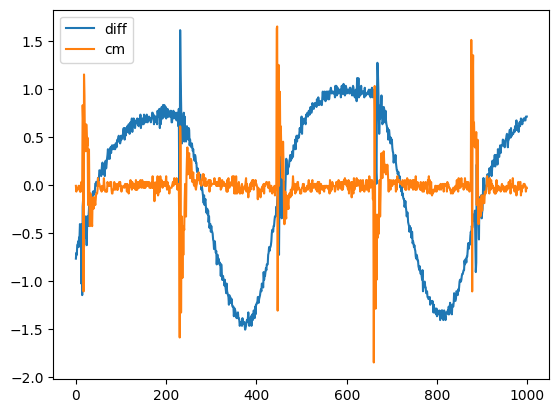

In [5]:
nnn=1000
plt.plot(ydm[:nnn], label='diff')
plt.plot(ycm[:nnn], label='cm')
plt.legend()

In [6]:
%%time
freqs, peak, avg, qp = receiver(ycm,1/Ts, rbw=9000, band='B')
#freqs2, peak2, avg2, qp2= receiver(sigfix/2,1/ts, rbw=9000, band='B')

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
CPU times: total: 12.6 s
Wall time: 11.2 s


In [7]:
%%time
#freqs, peak, avg, qp = receiver(ydm,1/Ts, rbw=9000, band='B')
freqs2, peak2, avg2, qp2= receiver(ydm,1/Ts, rbw=9000, band='B')

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
CPU times: total: 8.48 s
Wall time: 2.71 s


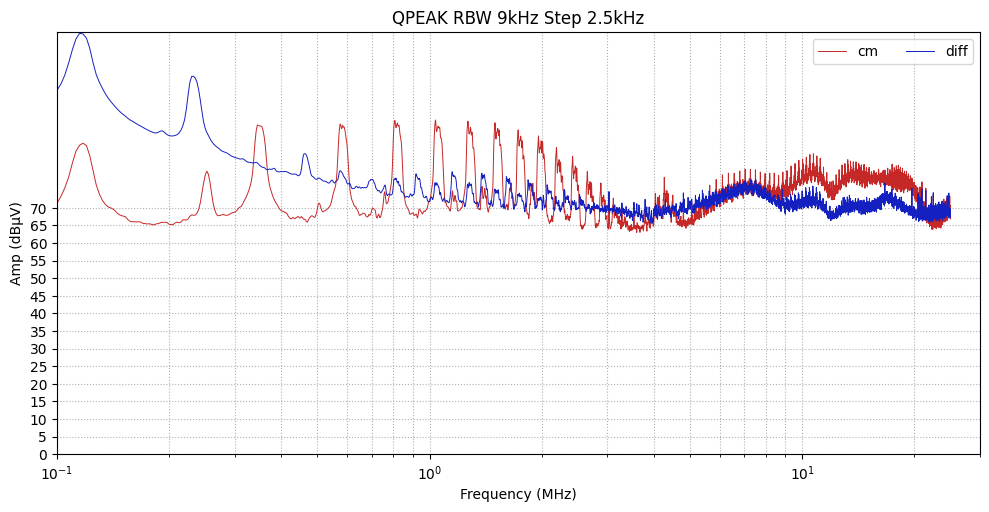

In [8]:
title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))
#plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red

plt.semilogx(freqs*1e-6, qp, label='cm', color='#C62828', linewidth=0.7)  # slightly lighter red

plt.semilogx(freqs2*1e-6, qp2, label='diff', color='#1520c0', linewidth=0.7)  # slightly lighter red
#plt.semilogx(freqs*1e-6, qp,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")








plt.ylim(0, 120)
plt.yticks(np.arange(0, 71, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

# CM DIFF V2 380v official

50.0 Mhz


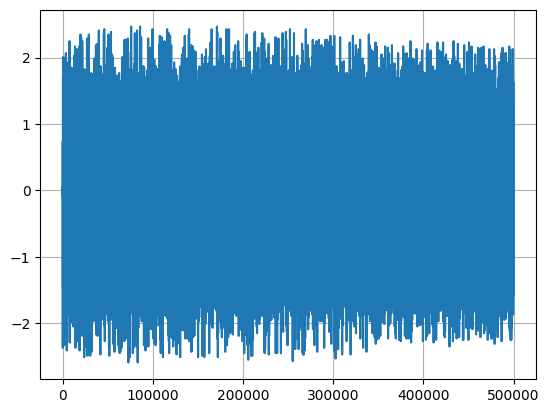

In [9]:
path = "EMI_2026-02-09_16-01-54-195/CH2_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
ycm=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")
plt.plot(ycm)
plt.grid()

50.0 Mhz


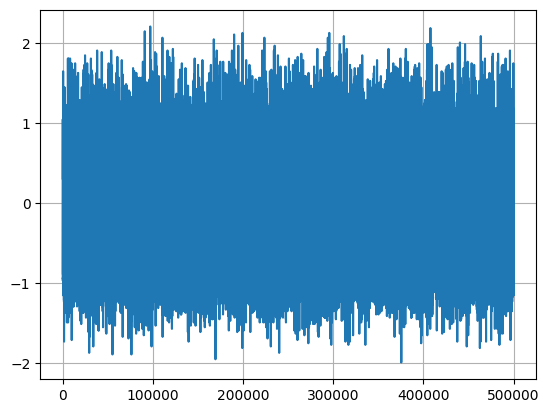

In [10]:
path = "EMI_2026-02-09_15-58-58-868/CH2_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
ydm=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")
plt.plot(ydm)
plt.grid()

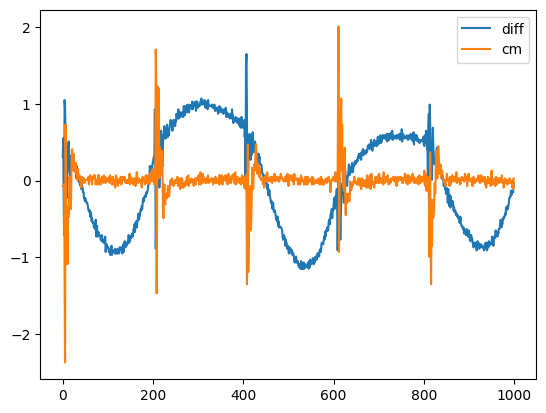

In [11]:
nnn=1000
plt.plot(ydm[:nnn], label='diff')
plt.plot(ycm[:nnn], label='cm')
plt.legend()

In [12]:
%%time
freqs, peak, avg, qp = receiver(ycm,1/Ts, rbw=9000, band='B')
#freqs2, peak2, avg2, qp2= receiver(sigfix/2,1/ts, rbw=9000, band='B')

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
CPU times: total: 7.62 s
Wall time: 2.73 s


In [13]:
%%time
#freqs, peak, avg, qp = receiver(ydm,1/Ts, rbw=9000, band='B')
freqs2, peak2, avg2, qp2= receiver(ydm/2,1/Ts, rbw=9000, band='B')

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
CPU times: total: 8.66 s
Wall time: 2.74 s


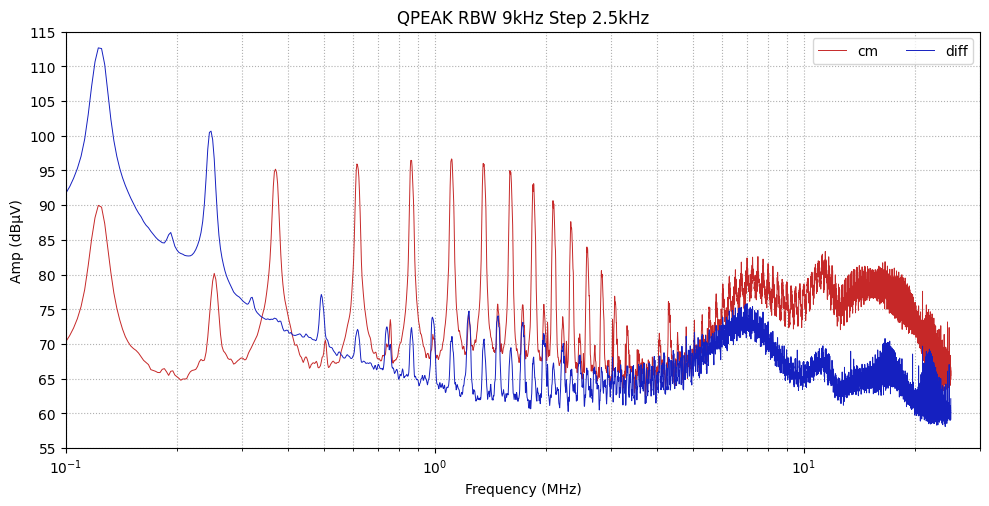

In [14]:
title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))
#plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red

plt.semilogx(freqs*1e-6, qp, label='cm', color='#C62828', linewidth=0.7)  # slightly lighter red

plt.semilogx(freqs2*1e-6, qp2, label='diff', color='#1520c0', linewidth=0.7)  # slightly lighter red
#plt.semilogx(freqs*1e-6, qp,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")








plt.ylim(55, 115)
plt.yticks(np.arange(55, 116, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

# HVP HVN 380V ref 

50.0 Mhz


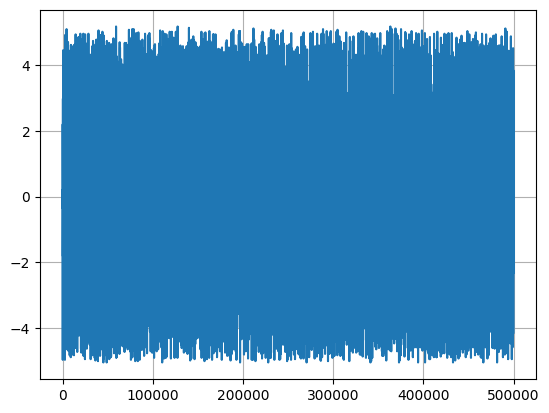

In [15]:
path = "EMI_2026-02-09_16-14-45-914/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
ycm=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")
plt.plot(ycm)
hvp = ycm
plt.grid()

50.0 Mhz


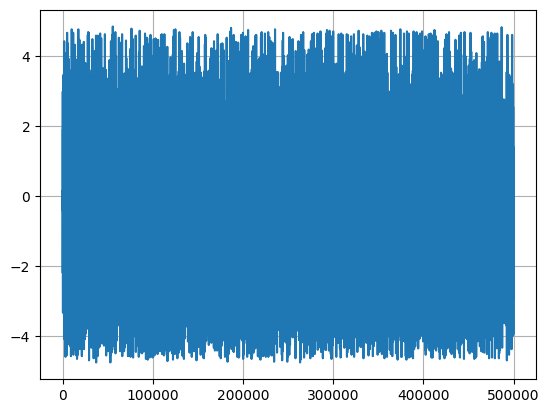

In [16]:
path = "EMI_2026-02-09_16-15-55-875/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
ydm=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")
plt.plot(ydm)
hvn=ydm
plt.grid()

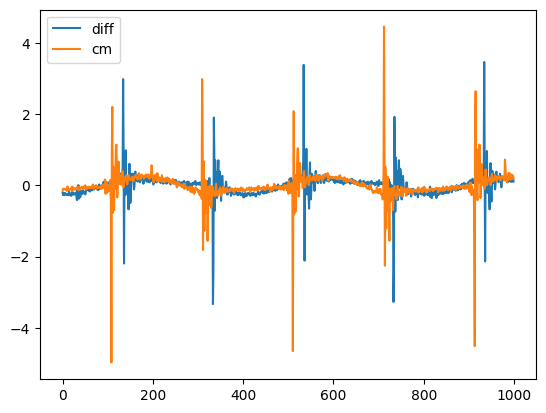

In [17]:
nnn=1000
plt.plot(ydm[:nnn], label='diff')
plt.plot(ycm[:nnn], label='cm')
plt.legend()

In [18]:
%%time
freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')
#freqs2, peak2, avg2, qp2= receiver(sigfix/2,1/ts, rbw=9000, band='B')

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
CPU times: total: 6.75 s
Wall time: 2.45 s


In [19]:
%%time
#freqs, peak, avg, qp = receiver(ydm,1/Ts, rbw=9000, band='B')
freqs2, peak2, avg2, qp2= receiver(hvn,1/Ts, rbw=9000, band='B')

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
CPU times: total: 7.2 s
Wall time: 2.45 s


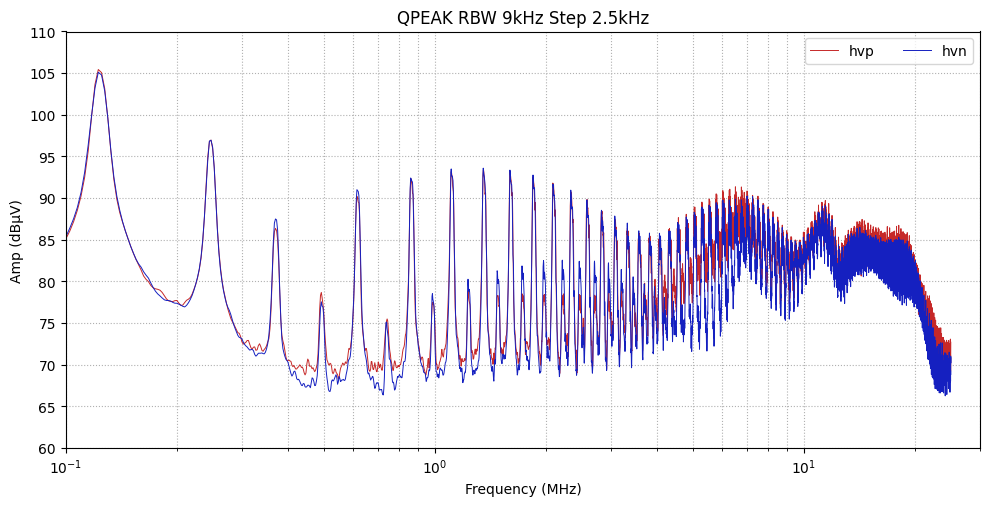

In [20]:
title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))
#plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red

plt.semilogx(freqs*1e-6, qp, label='hvp', color='#C62828', linewidth=0.7)  # slightly lighter red

plt.semilogx(freqs2*1e-6, qp2, label='hvn', color='#1520c0', linewidth=0.7)  # slightly lighter red
#plt.semilogx(freqs*1e-6, qp,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")








plt.ylim(60, 110)
plt.yticks(np.arange(60, 111, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

In [21]:
from copy import copy

In [22]:
hvpref = copy(hvp)

In [23]:
len(hvpref)

500000

In [24]:
labelold = "HVP, Ref: No EMC filter"
freqsr = copy(freqs)
qpr = copy(qp)

# ADD CM CHOCK

In [25]:
label = "HVP, add CMC only"

In [26]:
path = "EMI_2026-02-09_16-28-39-062/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
"""
print(1e-6/Ts,"Mhz")
plt.plot(hvp)
hvp = hvp
plt.grid()
"""

'\nprint(1e-6/Ts,"Mhz")\nplt.plot(hvp)\nhvp = hvp\nplt.grid()\n'

In [27]:
%%time
freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')
#freqs2, peak2, avg2, qp2= receiver(sigfix/2,1/ts, rbw=9000, band='B')

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
CPU times: total: 7.23 s
Wall time: 2.44 s


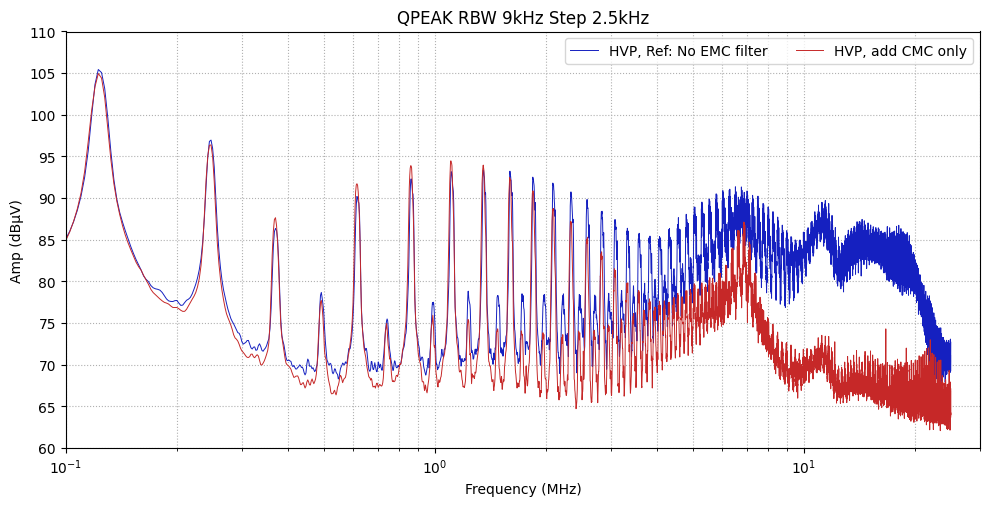

In [28]:
title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))
#plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red


plt.semilogx(freqsr*1e-6, qpr, label=labelold, color='#1520c0', linewidth=0.7)  # slightly lighter red


plt.semilogx(freqs*1e-6, qp, label=label, color='#C62828', linewidth=0.7)  # slightly lighter red


#plt.semilogx(freqs*1e-6, qp,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")








plt.ylim(60, 110)
plt.yticks(np.arange(60, 111, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

In [29]:
labelold = copy(label)
freqsr = copy(freqs)
qpr = copy(qp)
label = 'HVP, add CMC film capacitors'

# ADD CM capa and diff capa film + snubber 380v

50.0 Mhz


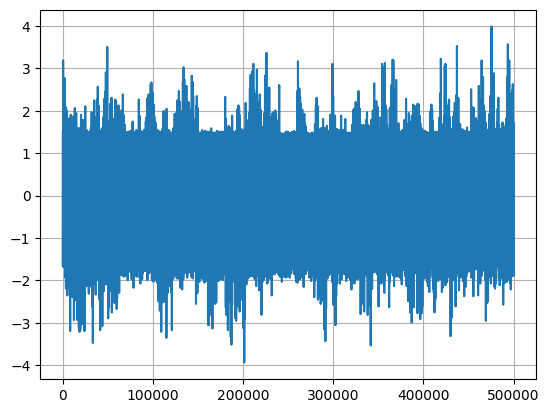

In [30]:
path = "EMI_2026-02-09_18-05-30-391/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")
plt.plot(hvp)
hvp = hvp
plt.grid()

In [31]:
%%time
freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')
#freqs2, peak2, avg2, qp2= receiver(sigfix/2,1/ts, rbw=9000, band='B')

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
CPU times: total: 5.58 s
Wall time: 1.98 s


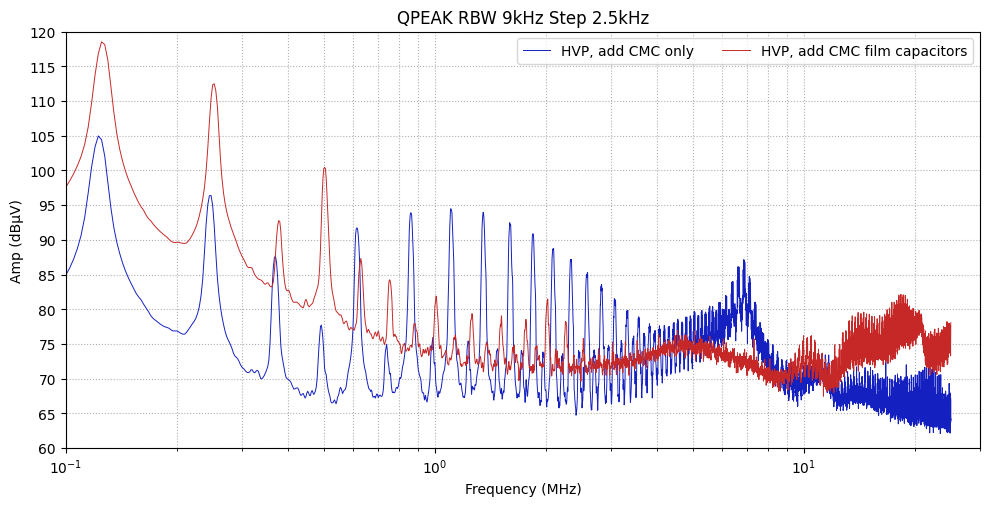

In [32]:
title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))
#plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red


plt.semilogx(freqsr*1e-6, qpr, label=labelold, color='#1520c0', linewidth=0.7)  # slightly lighter red


plt.semilogx(freqs*1e-6, qp, label=label, color='#C62828', linewidth=0.7)  # slightly lighter red


#plt.semilogx(freqs*1e-6, qp,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")








plt.ylim(60, 120)
plt.yticks(np.arange(60, 121, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

In [33]:
labelold = copy(label)
freqsr = copy(freqs)
qpr = copy(qp)
label = 'HVP, add 5 small capas 1nF CM'

# ADD CM SMALL CAPA 1nF 380v

In [34]:
path = "EMI_2026-02-09_18-19-20-917/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")




freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')

50.0 Mhz
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


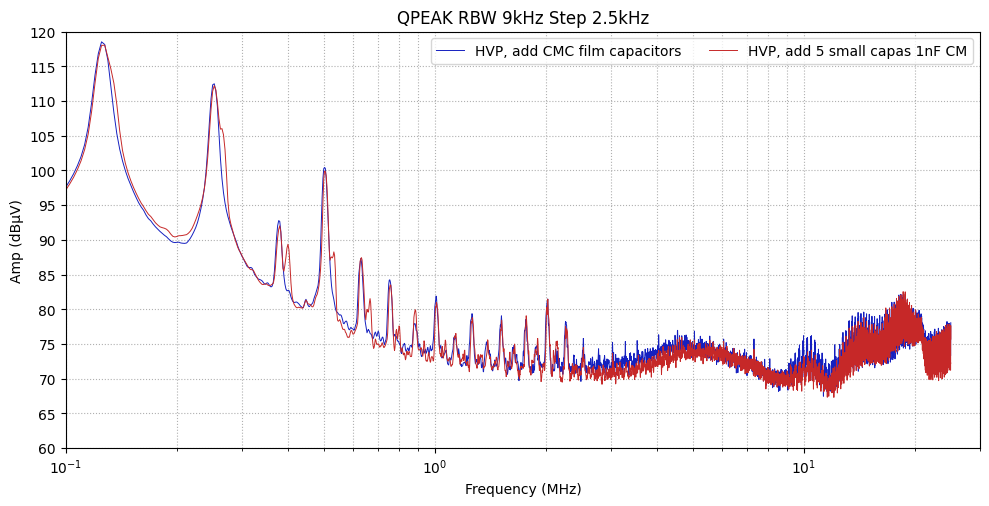

In [35]:
title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))
#plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red


plt.semilogx(freqsr*1e-6, qpr, label=labelold, color='#1520c0', linewidth=0.7)  # slightly lighter red


plt.semilogx(freqs*1e-6, qp, label=label, color='#C62828', linewidth=0.7)  # slightly lighter red


#plt.semilogx(freqs*1e-6, qp,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")








plt.ylim(60, 120)
plt.yticks(np.arange(60, 121, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

In [36]:
labelold = copy(label)
freqsr = copy(freqs)
qpr = copy(qp)
label = 'HVP, add diff snubber 220nF+2.4ohm'

# ADD snuber 220nF + 2.4 ohm 380v

50.0 Mhz
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


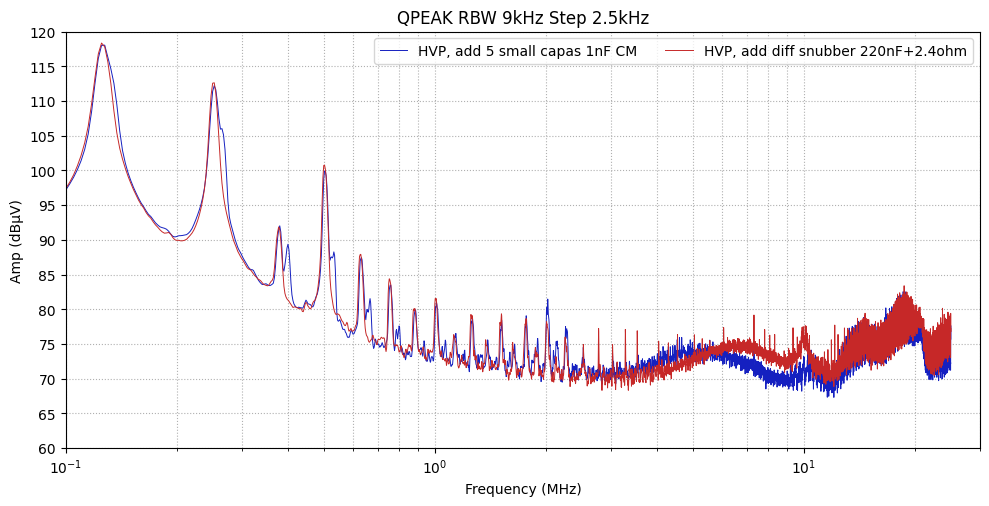

In [37]:
label = 'HVP, add diff snubber 220nF+2.4ohm'


path = "EMI_2026-02-10_10-22-44-960/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")




freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')





title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))
#plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red


plt.semilogx(freqsr*1e-6, qpr, label=labelold, color='#1520c0', linewidth=0.7)  # slightly lighter red


plt.semilogx(freqs*1e-6, qp, label=label, color='#C62828', linewidth=0.7)  # slightly lighter red


#plt.semilogx(freqs*1e-6, qp,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")








plt.ylim(60, 120)
plt.yticks(np.arange(60, 121, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()


In [38]:
len(hvp)*Ts

0.01

In [39]:
help(receiver)

Help on function receiver in module emi_receiver.src.emi_receiver:

receiver(signal, fs, rbw=9000, step=2500, band='B')
    FFT-based EMI Receiver Emulation.

    Parameters:
    -----------
    signal : array_like
        Input signal (Volts)
    fs : float
        Sampling Frequency (Hz)
    rbw : float
        Resolution Bandwidth (Hz). Default 9 kHz.
    step : float
        Frequency Step size (Hz). Default 2500 Hz (2.5 kHz).
        The code will use Zero-Padding interpolation to achieve this exact step.
    band : str
        CISPR Band ('A' or 'B'). 'B' is 150kHz-30MHz.

    Returns:
    --------
    freqs, peak_dBuV, avg_dBuV, qp_dBuV



In [40]:
labelold = copy(label)
freqsr = copy(freqs)
qpr = copy(qp)
label = 'HVP, add diff snubber 220nF+2.4ohm'

In [41]:
c=220e-9
R=2.4
to = R*c
w= 1/to
w/(2.3*14) # 58k


58817.993600602305

In [42]:
c=2.2e-9
R=240
to = R*c
w= 1/to
w/(2.3*14) # 58k


58817.993600602305

In [43]:
# add 10nf*2 +200 ohm is cm (Switching side: noise side)

# CM snubber 360ohm + 4.7nF by phase 380v

EMI_2026-02-10_10-50-50-273

50.0 Mhz
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


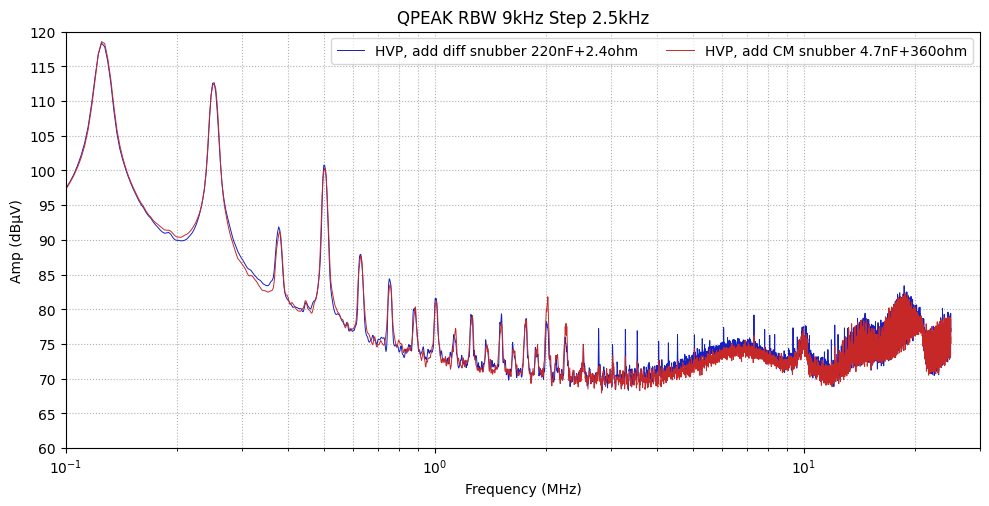

In [44]:
label = 'HVP, add CM snubber 4.7nF+360ohm'


path = "EMI_2026-02-10_10-50-50-273/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")




freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')





title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))
#plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red


plt.semilogx(freqsr*1e-6, qpr, label=labelold, color='#1520c0', linewidth=0.7)  # slightly lighter red


plt.semilogx(freqs*1e-6, qp, label=label, color='#C62828', linewidth=0.7)  # slightly lighter red


#plt.semilogx(freqs*1e-6, qp,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")








plt.ylim(60, 120)
plt.yticks(np.arange(60, 121, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()


In [ ]:
labelold = copy(label)
freqsr = copy(freqs)
qpr = copy(qp)
label = 'HVP, add diff snubber 220nF+2.4ohm'

# FINAL 

In [43]:
path = "EMI_2026-02-09_18-19-20-917/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")




freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')

50.0 Mhz
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


In [44]:
path = "EMI_2026-02-09_18-20-26-964/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvn=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")




freqs2, peak2, avg2, qp2 = receiver(hvn,1/Ts, rbw=9000, band='B')

50.0 Mhz
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


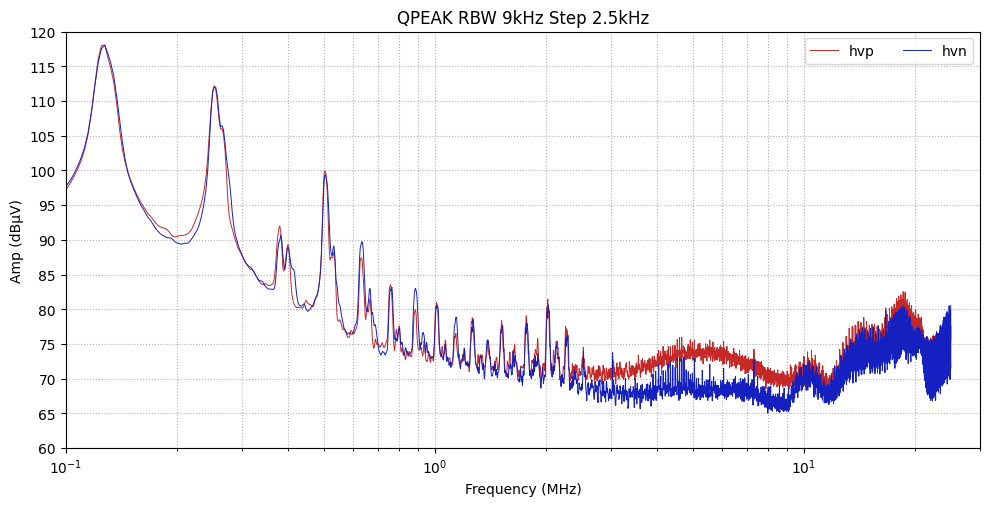

In [45]:
title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))
#plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red

plt.semilogx(freqs*1e-6, qp, label='hvp', color='#C62828', linewidth=0.7)  # slightly lighter red

plt.semilogx(freqs2*1e-6, qp2, label='hvn', color='#1520c0', linewidth=0.7)  # slightly lighter red
#plt.semilogx(freqs*1e-6, qp,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")








plt.ylim(60, 120)
plt.yticks(np.arange(60, 121, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

# BEFORE AFTER FILTER HVP 

In [46]:
path = "EMI_2026-02-09_18-19-20-917/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")




freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')

50.0 Mhz
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


In [47]:
#path = "EMI_2026-02-09_18-20-26-964/CH3_raw.npy"
path = "EMI_2026-02-09_16-14-45-914/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvn=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")




freqs2, peak2, avg2, qp2 = receiver(hvn,1/Ts, rbw=9000, band='B')

50.0 Mhz
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


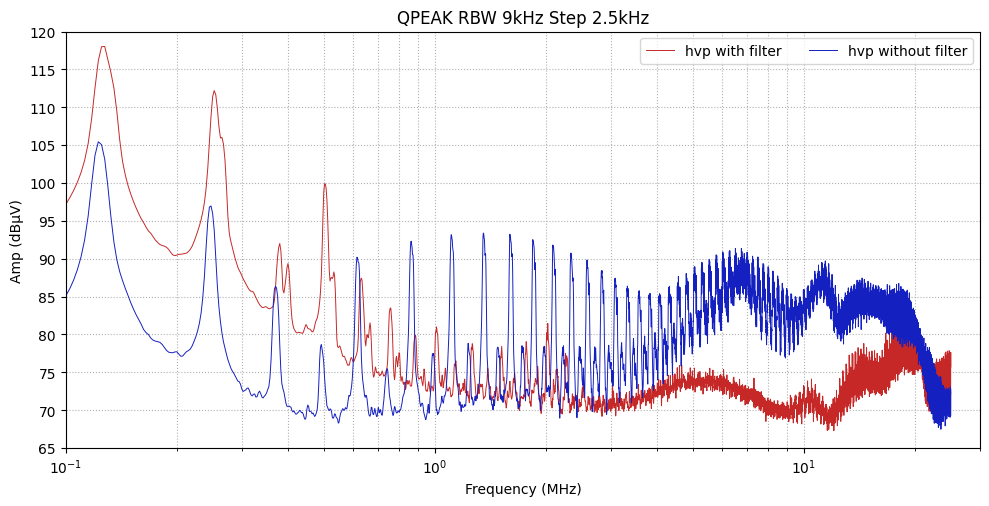

In [48]:
title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))
#plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red

plt.semilogx(freqs*1e-6, qp, label='hvp with filter', color='#C62828', linewidth=0.7)  # slightly lighter red

plt.semilogx(freqs2*1e-6, qp2, label='hvp without filter', color='#1520c0', linewidth=0.7)  # slightly lighter red
#plt.semilogx(freqs*1e-6, qp,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")








plt.ylim(65, 120)
plt.yticks(np.arange(65, 121, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

In [49]:
#cm res 
C=2.2e-9*2
L=400e-6
1/(2*np.pi*np.sqrt(L*C))

np.float64(119967.55221958704)

# Only Power supplay + LISN

50.0 Mhz
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


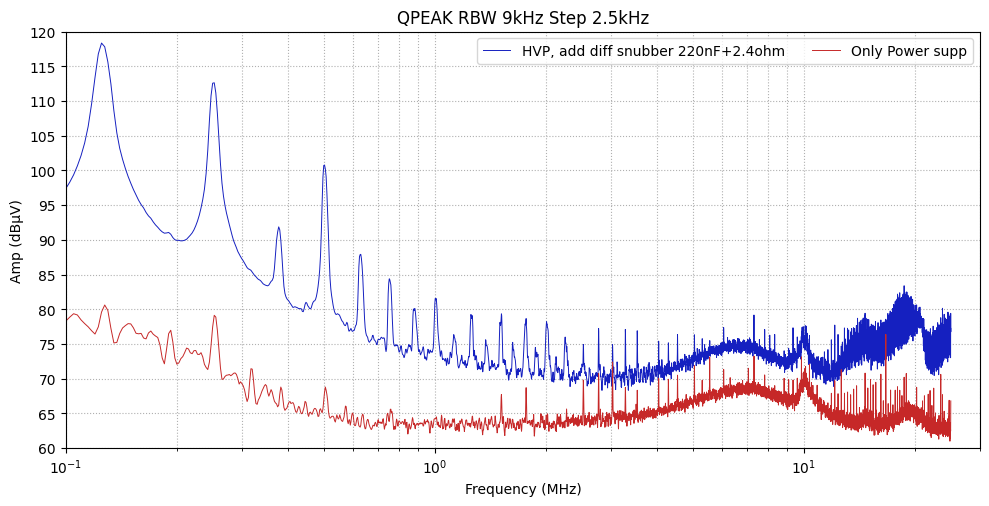

In [46]:


label = 'Only Power supp'


path = "EMI_2026-02-10_11-02-27-557/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")




freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')





title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))
#plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red


plt.semilogx(freqsr*1e-6, qpr, label=labelold, color='#1520c0', linewidth=0.7)  # slightly lighter red


plt.semilogx(freqs*1e-6, qp, label=label, color='#C62828', linewidth=0.7)  # slightly lighter red


#plt.semilogx(freqs*1e-6, qp,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")








plt.ylim(60, 120)
plt.yticks(np.arange(60, 121, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()


# Only fly back 

In [47]:
labelold = copy(label)
freqsr = copy(freqs)
qpr = copy(qp)
label = 'only flyback'

50.0 Mhz
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


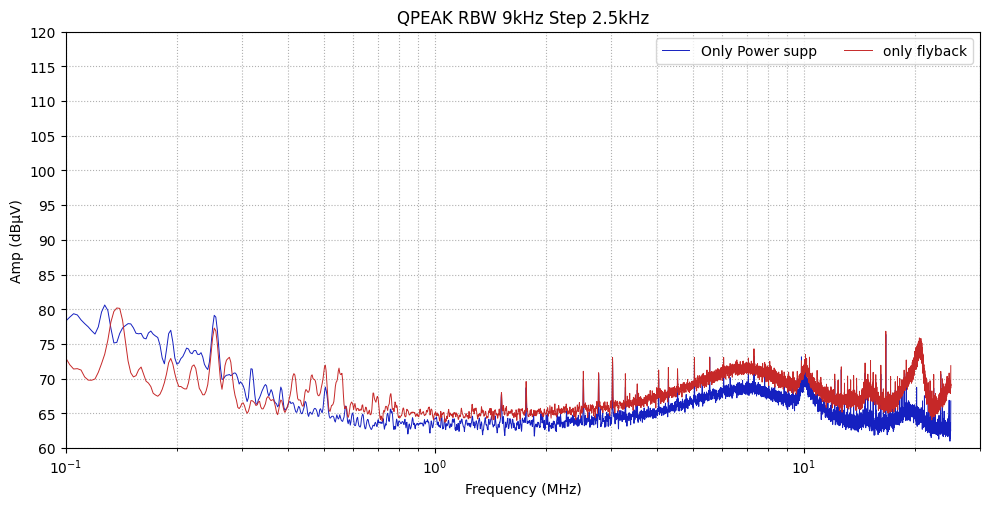

In [48]:



path = "EMI_2026-02-10_11-07-47-096/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])
print(1e-6/Ts,"Mhz")




freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')





title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))
#plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red


plt.semilogx(freqsr*1e-6, qpr, label=labelold, color='#1520c0', linewidth=0.7)  # slightly lighter red


plt.semilogx(freqs*1e-6, qp, label=label, color='#C62828', linewidth=0.7)  # slightly lighter red


#plt.semilogx(freqs*1e-6, qp,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")








plt.ylim(60, 120)
plt.yticks(np.arange(60, 121, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()



# Rg impact

In [58]:
5.1*3/(5.1+3)

1.8888888888888888

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


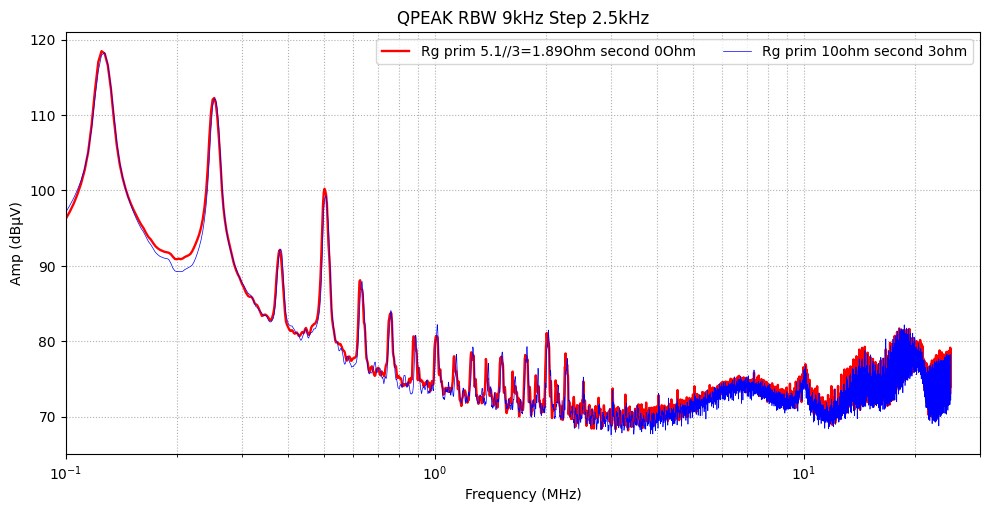

In [61]:
title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))

label = "Rg prim 5.1//3=1.89Ohm second 0Ohm"
path = "EMI_2026-02-10_11-15-54-358/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])

freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')
plt.semilogx(freqs*1e-6, qp,c="r", label=label, linewidth=1.7)  # slightly lighter red





label = "Rg prim 10ohm second 3ohm"
path = "EMI_2026-02-10_11-18-31-655/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])

freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')
plt.semilogx(freqs*1e-6, qp,c="b", label=label, linewidth=0.5)  # slightly lighter red



#plt.ylim(60, 120)
#plt.yticks(np.arange(60, 121, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

# GND impact

In [58]:
5.1*3/(5.1+3)

1.8888888888888888

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


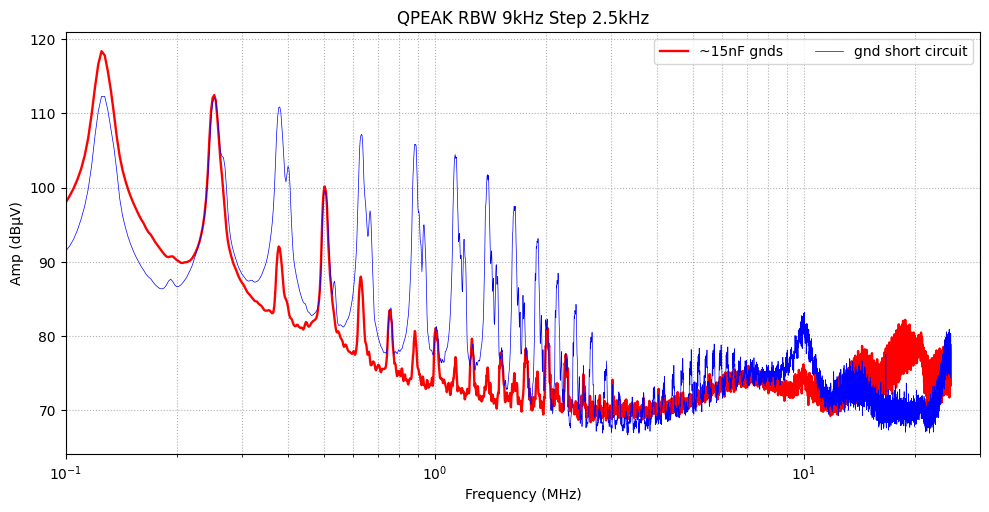

In [62]:
title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))

label = "~15nF gnds "
path = "EMI_2026-02-10_11-34-04-039/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])

freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')
plt.semilogx(freqs*1e-6, qp,c="r", label=label, linewidth=1.7)  # slightly lighter red





label = "gnd short circuit"
path = "EMI_2026-02-10_11-40-07-628/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])

freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')
plt.semilogx(freqs*1e-6, qp,c="b", label=label, linewidth=0.5)  # slightly lighter red



#plt.ylim(60, 120)
#plt.yticks(np.arange(60, 121, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

# return to cm snubber 4n7 360hom

In [ ]:
#

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


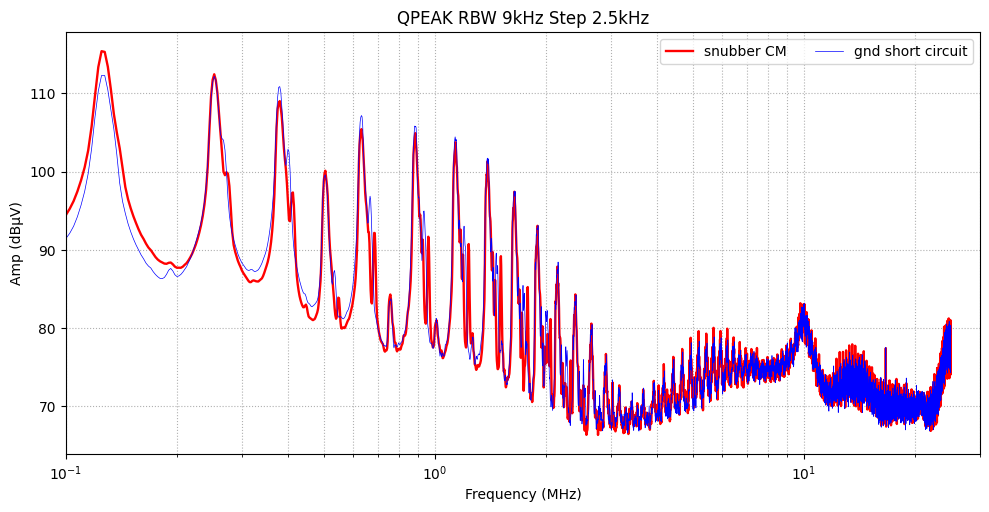

In [63]:
title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))

label = "snubber CM"
path = "EMI_2026-02-10_11-46-43-797/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])

freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')
plt.semilogx(freqs*1e-6, qp,c="r", label=label, linewidth=1.7)  # slightly lighter red





label = "gnd short circuit"
path = "EMI_2026-02-10_11-40-07-628/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])

freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')
plt.semilogx(freqs*1e-6, qp,c="b", label=label, linewidth=0.5)  # slightly lighter red



#plt.ylim(60, 120)
#plt.yticks(np.arange(60, 121, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

# RETUNR TO DIFF SNUBBER 220N + 2.4 OHM 

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


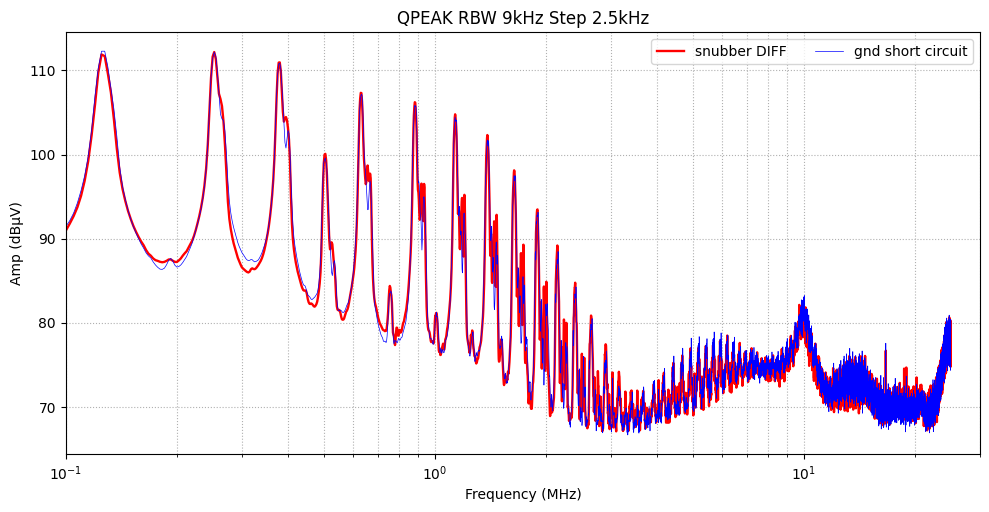

In [64]:
title="QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))

label = "snubber DIFF"
path = "EMI_2026-02-10_11-51-32-964/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])

freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')
plt.semilogx(freqs*1e-6, qp,c="r", label=label, linewidth=1.7)  # slightly lighter red





label = "gnd short circuit"
path = "EMI_2026-02-10_11-40-07-628/CH3_raw.npy"
arr= np.load(path)
yraw=arr.flatten() 
with open(path.replace("_raw.npy","_seeting.txt")) as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)


y=raw_to_volte(yraw, dic)
y=y-y.mean()
hvp=y/float(dic['SCALE'])


Ts=float(dic['x_increment'])

freqs, peak, avg, qp = receiver(hvp,1/Ts, rbw=9000, band='B')
plt.semilogx(freqs*1e-6, qp,c="b", label=label, linewidth=0.5)  # slightly lighter red



#plt.ylim(60, 120)
#plt.yticks(np.arange(60, 121, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

# END

array([0.])